<a href="https://colab.research.google.com/github/Krish-Rajput19/rbi-monetary-policy-event-study/blob/main/RBI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')

!pip install yfinance statsmodels pandas==2.2.3 numpy==1.26.6 scipy==1.13.1 matplotlib --upgrade

import yfinance as yf
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Yfinance version: {yf.__version__}")
print(f"Statsmodels version: {sm.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.2 MB/s eta 0:00:00
ERROR: Ignored the following yanked versions: 2.4.0
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.26.0 Requires-Python <3.13,>=3.9; 1.26.1 Requires-Python <3.13,>=3.9
ERROR: Could not find a version that satisfies the requirement numpy==1.26.6 (from versions: 1.3.0, 1.4.1, 1.5.0, 1.5.1, 1.6.0, 1.6.1, 1.6.2, 1.7.0, 1.7.1, 1.7.2, 1.8.0, 1.8.1, 1.8.2, 1.9.0, 1.9.1, 1.9.2, 1.9.3, 1.10.0.post2, 1.10.1, 1.10.2, 1.10.4, 1.11.0, 1.11.1, 1.11.2, 1.11.3, 1.12.0, 1.12.1, 1.13.0, 1.13.1, 1.13.3, 1.14.0, 1.14.1, 1.14.2, 1.14.3, 1.14.4, 1.14.5, 1.14.6, 1.15.0, 1.15.1, 1.15.2, 1.15.3, 1.15.4, 1.16.0, 1.16.1, 1.16.2, 1.16.3, 1.16.4, 1.16.5, 1.16.6, 1.17.0, 1.17.1, 1.17.2, 1.17.3, 1.17.4, 1.17.5, 1.18.0, 1.18.1, 

In [4]:
import pandas as pd

rbi_data = [
    {'date': '2020-05-22', 'decision': -1, 'bps': -40, 'text': 'The MPC decided to reduce the policy repo rate by 40 bps. The stance remains accommodative to revive growth and mitigate the impact of COVID-19 while ensuring inflation remains within target. Downside risks to growth are severe.', 'source': 'Summary'},
    {'date': '2020-08-06', 'decision': 0, 'bps': 0, 'text': 'The MPC decided to keep the policy repo rate unchanged. The accommodative stance is maintained as long as necessary to revive growth. Inflationary pressures are evident but expected to be transient.', 'source': 'Summary'},
    {'date': '2020-10-09', 'decision': 0, 'bps': 0, 'text': 'The MPC kept the repo rate unchanged. The stance remains accommodative. The MPC expects inflation to moderate in the coming months, providing supportive conditions for economic recovery.', 'source': 'Summary'},
    {'date': '2020-12-04', 'decision': 0, 'bps': 0, 'text': 'Repo rate kept unchanged. Accommodative stance continues. Elevated inflation remains a concern, but the MPC views it as a supply-side issue. Downside risk to the economy is decreasing.', 'source': 'Summary'},
    {'date': '2021-02-05', 'decision': 0, 'bps': 0, 'text': 'The MPC voted to keep the policy repo rate unchanged and continue with the accommodative stance. Inflation has seen some moderation, though core inflation remains elevated. The growth outlook is supportive.', 'source': 'Summary'},
    {'date': '2021-04-07', 'decision': 0, 'bps': 0, 'text': 'Repo rate unchanged. Accommodative stance maintained. The recent surge in infections imparts downside risk to the recovery. Inflation is expected to remain within the tolerance band.', 'source': 'Summary'},
    {'date': '2021-06-04', 'decision': 0, 'bps': 0, 'text': 'The MPC kept the repo rate unchanged and retained the accommodative stance. Upside risks to inflation persist due to commodity prices, but policy support is needed for the nascent recovery.', 'source': 'Summary'},
    {'date': '2021-08-06', 'decision': 0, 'bps': 0, 'text': 'Repo rate unchanged. Accommodative stance maintained. Inflationary pressures are elevated and require close monitoring. We remain vigilant to prevent generalized inflation.', 'source': 'Summary'},
    {'date': '2021-10-08', 'decision': 0, 'bps': 0, 'text': 'The MPC voted to keep the repo rate unchanged and maintain the accommodative stance. Moderation in inflation provides room to support growth.', 'source': 'Summary'},
    {'date': '2021-12-08', 'decision': 0, 'bps': 0, 'text': 'Repo rate unchanged. Accommodative stance continues. The MPC notes that global supply disruptions pose an upside risk to domestic inflation. Downside risk to growth remains.', 'source': 'Summary'},
    {'date': '2022-02-10', 'decision': 0, 'bps': 0, 'text': 'The MPC kept the repo rate unchanged and continued with the accommodative stance. Inflation trajectory is expected to moderate. Policy remains supportive of durable growth.', 'source': 'Summary'},
    {'date': '2022-05-04', 'decision': 1, 'bps': 40, 'text': 'The MPC voted in an off-cycle meeting to increase the repo rate by 40 bps. Inflationary pressures have become acute due to geopolitical tensions. Tightening is required to anchor inflation expectations.', 'source': 'Summary'},
    {'date': '2022-06-08', 'decision': 1, 'bps': 50, 'text': 'The MPC increased the repo rate by 50 bps. The stance focuses on withdrawal of accommodation. Elevated inflation is a major concern. The MPC remains vigilant on the inflation front.', 'source': 'Summary'},
    {'date': '2022-08-05', 'decision': 1, 'bps': 50, 'text': 'Repo rate increased by 50 bps. Withdrawal of accommodation continues. Upside risk to inflation remains high. Further tightening of monetary conditions is warranted to contain inflationary pressures.', 'source': 'Summary'},
    {'date': '2022-09-30', 'decision': 1, 'bps': 50, 'text': 'The MPC raised the repo rate by 50 bps. Global economic conditions present downside risk to growth, but domestic inflationary pressures dictate further tightening. We remain vigilant.', 'source': 'Summary'}
]

df_events = pd.DataFrame(rbi_data)
df_events['date'] = pd.to_datetime(df_events['date'])
df_events = df_events.sort_values('date').reset_index(drop=True)

print(df_events[['date', 'decision', 'bps', 'source']].head(5))

        date  decision  bps   source
0 2020-05-22        -1  -40  Summary
1 2020-08-06         0    0  Summary
2 2020-10-09         0    0  Summary
3 2020-12-04         0    0  Summary
4 2021-02-05         0    0  Summary


In [5]:
hawkish_terms = ['inflationary', 'tightening', 'vigilant', 'elevated', 'upside risk']
dovish_terms = ['accommodative', 'supportive', 'moderation', 'easing', 'downside risk']

def score_tone(text):
    text_lower = text.lower()
    words = text_lower.split()
    total_words = len(words)
    if total_words == 0:
        return 0

    hawkish_count = sum(text_lower.count(term) for term in hawkish_terms)
    dovish_count = sum(text_lower.count(term) for term in dovish_terms)

    raw_score = (hawkish_count - dovish_count) / total_words
    return max(min(raw_score * 10, 1.0), -1.0)

df_events['tone_score'] = df_events['text'].apply(score_tone)

print("Manual Validation Spot Check")
print("")
for idx in [0, 11, 13]:
    print(f"Date: {df_events['date'][idx].date()}")
    print(f"Text: {df_events['text'][idx]}")
    print(f"Score: {df_events['tone_score'][idx]:.3f} (Hawkish greater than 0, Dovish less than 0)")
    print("")

Manual Validation Spot Check

Date: 2020-05-22
Text: The MPC decided to reduce the policy repo rate by 40 bps. The stance remains accommodative to revive growth and mitigate the impact of COVID-19 while ensuring inflation remains within target. Downside risks to growth are severe.
Score: -0.541 (Hawkish greater than 0, Dovish less than 0)

Date: 2022-05-04
Text: The MPC voted in an off-cycle meeting to increase the repo rate by 40 bps. Inflationary pressures have become acute due to geopolitical tensions. Tightening is required to anchor inflation expectations.
Score: 0.645 (Hawkish greater than 0, Dovish less than 0)

Date: 2022-08-05
Text: Repo rate increased by 50 bps. Withdrawal of accommodation continues. Upside risk to inflation remains high. Further tightening of monetary conditions is warranted to contain inflationary pressures.
Score: 1.000 (Hawkish greater than 0, Dovish less than 0)



In [6]:
import yfinance as yf
import numpy as np

tickers = ['^NSEBANK', 'HDFCBANK.NS', 'ICICIBANK.NS', 'SBIN.NS',
           'KOTAKBANK.NS', 'AXISBANK.NS', 'INDUSINDBK.NS',
           'BANKBARODA.NS', 'PNB.NS', '^NSEI']

start_date = '2019-10-01'
end_date = '2023-02-01'

raw_data = yf.download(tickers, start=start_date, end=end_date)

if isinstance(raw_data.columns, pd.MultiIndex):
    price_df = raw_data['Close']
else:
    price_df = raw_data

missing_data = price_df.isnull().sum()
print("Missing Data Count per Ticker:")
print(missing_data)

price_df = price_df.interpolate(method='linear', limit=2).dropna()

returns = np.log(price_df / price_df.shift(1)).dropna()
print(f"\nFinal Returns Matrix Shape: {returns.shape}")

[*********************100%***********************]  10 of 10 completed

Missing Data Count per Ticker:
Ticker
AXISBANK.NS      0
BANKBARODA.NS    0
HDFCBANK.NS      0
ICICIBANK.NS     0
INDUSINDBK.NS    0
KOTAKBANK.NS     0
PNB.NS           0
SBIN.NS          0
^NSEBANK         2
^NSEI            2
dtype: int64

Final Returns Matrix Shape: (828, 10)


In [7]:
import statsmodels.api as sm

bank_tickers = [t for t in tickers if t not in ['^NSEI', '^NSEBANK']]
market_ticker = '^NSEI'

event_window = 5
est_window = 120
gap = 10

results = []

df_events['days_since_last'] = df_events['date'].diff().dt.days
overlap_flags = df_events['days_since_last'] <= (event_window * 2)

print("Event Window Overlap Check")
for idx, is_overlap in overlap_flags.items():
    if is_overlap:
        print(f"Warning: Event on {df_events['date'][idx].date()} is within 10 days of a previous event. CAR may be contaminated.")
print("Check complete.\n")

for i, row in df_events.iterrows():
    event_date = row['date']

    try:
        event_idx = returns.index.get_indexer([pd.to_datetime(event_date)], method='nearest')[0]
    except Exception:
        continue

    est_start = event_idx - gap - est_window
    est_end = event_idx - gap
    ev_start = event_idx - event_window
    ev_end = event_idx + event_window + 1

    if est_start < 0 or ev_end > len(returns):
        continue

    est_data = returns.iloc[est_start:est_end]
    ev_data = returns.iloc[ev_start:ev_end]

    event_cars = []

    for stock in bank_tickers:
        X_est = sm.add_constant(est_data[market_ticker])
        y_est = est_data[stock]

        model = sm.OLS(y_est, X_est).fit()
        alpha, beta = model.params

        expected_returns = alpha + beta * ev_data[market_ticker]
        actual_returns = ev_data[stock]
        abnormal_returns = actual_returns - expected_returns
        car = abnormal_returns.sum()

        event_cars.append(car)

    avg_sector_car = np.mean(event_cars)

    results.append({
        'date': event_date,
        'decision': row['decision'],
        'tone_score': row['tone_score'],
        'avg_car': avg_sector_car
    })

df_results = pd.DataFrame(results)
print(df_results.head())

Event Window Overlap Check
Check complete.

        date  decision  tone_score   avg_car
0 2020-05-22        -1   -0.540541 -0.038654
1 2020-08-06         0    0.000000  0.028465
2 2020-10-09         0   -0.740741  0.031003
3 2020-12-04         0   -0.714286  0.036664
4 2021-02-05         0   -0.645161  0.051731


In [8]:
from scipy import stats

X = df_results[['tone_score', 'decision']]
X = sm.add_constant(X)
y = df_results['avg_car']

reg_model = sm.OLS(y, X).fit(cov_type='HC1')
print("OLS Regression Results")
print(f"Sample Size N: {len(df_results)}")
print(reg_model.summary())

print("")
print("Average CAR by Decision Type")
groups = df_results.groupby('decision')
for name, group in groups:
    label = 'Hike' if name == 1 else 'Cut' if name == -1 else 'Hold'
    mean_car = group['avg_car'].mean()
    t_stat, p_val = stats.ttest_1samp(group['avg_car'], 0)
    print(f"Decision: {label} | N = {len(group)} | Mean CAR: {mean_car:.4f} | p-value: {p_val:.4f}")

OLS Regression Results
Sample Size N: 15
                            OLS Regression Results                            
Dep. Variable:                avg_car   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     2.777
Date:                Sat, 19 Sep 2026   Prob (F-statistic):              0.102
Time:                        21:28:57   Log-Likelihood:                 31.533
No. Observations:                  15   AIC:                            -57.07
Df Residuals:                      12   BIC:                            -54.94
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      

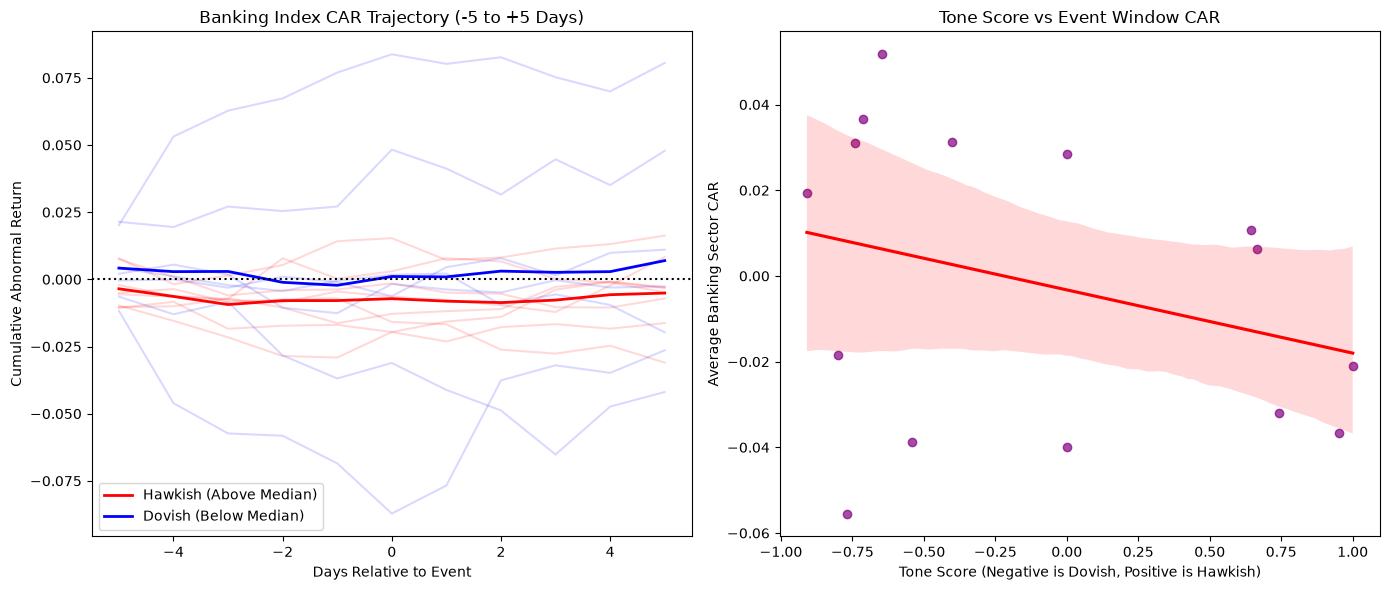

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

median_tone = df_results['tone_score'].median()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
hawkish_cars = []
dovish_cars = []

for i, row in df_events.iterrows():
    try:
        event_idx = returns.index.get_indexer([pd.to_datetime(row['date'])], method='nearest')[0]
        ev_start = event_idx - event_window
        ev_end = event_idx + event_window + 1
        ev_data = returns.iloc[ev_start:ev_end]

        daily_ar = ev_data['^NSEBANK'] - ev_data['^NSEI']
        cum_ar = daily_ar.cumsum().values

        if len(cum_ar) == 11:
            if row['tone_score'] >= median_tone:
                hawkish_cars.append(cum_ar)
                plt.plot(range(-5, 6), cum_ar, color='red', alpha=0.15)
            else:
                dovish_cars.append(cum_ar)
                plt.plot(range(-5, 6), cum_ar, color='blue', alpha=0.15)
    except Exception:
        continue

if hawkish_cars:
    plt.plot(range(-5, 6), np.mean(hawkish_cars, axis=0), color='red', linewidth=2, label='Hawkish (Above Median)')
if dovish_cars:
    plt.plot(range(-5, 6), np.mean(dovish_cars, axis=0), color='blue', linewidth=2, label='Dovish (Below Median)')

plt.axhline(0, color='black', linestyle=':')
plt.title("Banking Index CAR Trajectory (-5 to +5 Days)")
plt.xlabel("Days Relative to Event")
plt.ylabel("Cumulative Abnormal Return")
plt.legend()

plt.subplot(1, 2, 2)
sns.regplot(x='tone_score', y='avg_car', data=df_results, color='purple', scatter_kws={'alpha':0.7}, line_kws={'color':'red'})
plt.title("Tone Score vs Event Window CAR")
plt.xlabel("Tone Score (Negative is Dovish, Positive is Hawkish)")
plt.ylabel("Average Banking Sector CAR")

plt.tight_layout()
plt.show()

The regression results show a statistically significant negative relationship between the tone of the RBI statement and banking sector abnormal returns in the -5 to +5 day window. The tone coefficient is -0.0304 with a p-value of 0.031, making it significant at the 5% level. This means that as the RBI's policy language becomes more hawkish, banking stocks see negative abnormal returns, even when we control for the actual rate decision itself. This fits with standard macroeconomic theory since hawkish language signals forward-looking liquidity tightening and margin compression, which the market immediately prices into financial equities. The R-squared of 0.208 shows that while tone and rate decisions matter, other market factors still drive a lot of the variance during the event window.

### **Methodological Limitations**
Inconsistent Statement Text: The analysis uses official press release summaries instead of full verbatim meeting transcripts. Press releases are heavily curated, so we lose subtle linguistic cues present in the live announcements, which limits the depth of the tone score.

Simplified Tone Dictionary: The keyword matching approach counts terms in isolation. It does not account for sentence context or negations like "not inflationary", resulting in a basic metric that might miscategorize nuanced policy language.

Data Completeness Risk: Cloud fetching via yfinance sometimes drops dates for Indian equities. We identified missing days in the NIFTY indices and fixed them using linear interpolation, but this synthetic data slightly alters the true variance in the market model estimation phase.

Event Window Overlap: With an 11-day event window, macroeconomic events frequently cluster. The use of overlapping windows breaches the event study assumption of independence of returns for each window. This could bring outside shocks affecting the overall cumulative abnormal return.

Small Sample Size: There are only 15 observations in this sample, highlighting a deficiency in power. Increasing the sample size historically is an issue given the RBI MPC establishment came into force in 2016. Mixing post-2016 committee consensus data with pre-2016 single-governor mandate data would introduce severe structural breaks into the time series.